<style>
:root{--navy:#102a43;--blue:#184e77;--teal:#2a9d8f;--gold:#e9c46a;--red:#e76f51;--ink:#172033;--pale:#edf5fb}
.hero{padding:38px 42px;border-radius:24px;color:#f8fbff;background:radial-gradient(circle at 92% 8%,rgba(255,255,255,.16) 0 8%,transparent 9%),linear-gradient(125deg,var(--navy),var(--blue) 55%,var(--teal));box-shadow:0 16px 38px #102a433d;font-family:Inter,'Segoe UI',sans-serif}.hero h1{font-size:38px;margin:18px 0 8px;color:white}.chips{display:flex;gap:8px;flex-wrap:wrap}.chips span{padding:6px 13px;border:1px solid #ffffff55;border-radius:999px;background:#ffffff20;font-size:11px;font-weight:800}.grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(205px,1fr));gap:13px;margin-top:24px}.card{padding:14px 16px;border:1px solid #ffffff44;border-radius:12px;background:#ffffff12}.section{margin:28px 0 14px;padding:16px 22px;border-radius:14px;background:linear-gradient(90deg,var(--navy),var(--blue));color:white}.section h2{margin:0;color:white}.call{padding:18px 22px;margin:14px 0;border:1px solid #c9d9e6;border-left:6px solid var(--teal);border-radius:13px;background:var(--pale);color:var(--ink);line-height:1.7}.warn{border-left-color:var(--red);background:#fff2ed}.proof{border-left-color:var(--gold);background:#fff9e9}.metric{display:inline-block;min-width:145px;padding:12px 14px;margin:4px;border-radius:10px;background:#e5f5f2;color:#184e77;text-align:center}.metric b{display:block;font-size:21px}table{font-size:14px}th{background:#184e77!important;color:white!important;text-align:left!important}td,th{padding:9px!important}code{background:#102a4312;padding:2px 5px;border-radius:4px}
</style><div class="hero"><div class="chips"><span>DEEP LEARNING</span><span>PROYECTO 1</span><span>V5 INTEGRADA</span><span>GRUPO 1 · SECCIÓN 30</span></div><h1>Monitoreo transaccional: detectar lo que el orden revela</h1><p style="font-size:20px">Comparación rubricada A/B/C, falsificación temporal y decisión económica</p><div class="grid"><div class="card"><b>Institución</b><br>Universidad del Valle de Guatemala</div><div class="card"><b>Curso</b><br>Deep Learning y Sistemas Inteligentes</div><div class="card"><b>Docente</b><br>Kevin Recinos</div><div class="card"><b>Integrantes</b><br>Wilson Alejandro Calderón Argueta · 22018<br>Pablo Daniel Barillas Moreno · 22193</div><div class="card"><b>Datos</b><br>IEEE-CIS · 590,540 transacciones</div><div class="card"><b>Candidato</b><br>A · LightGBM expertos V4</div></div></div>

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score
from IPython.display import Image, display
ROOT=Path.cwd()
if not (ROOT/'artefactos').exists(): ROOT=ROOT.parents[1]
R=json.loads((ROOT/'artefactos/v5/resultados_v5.json').read_text(encoding='utf-8'))
VAL=pd.read_csv(ROOT/'artefactos/v5/predicciones_validacion_v5.csv')
BENCH=pd.read_csv(ROOT/'artefactos/v5/predicciones_benchmark_v5.csv')
R['candidato']

{'modelo': 'A_V4',
 'criterio': 'C solo puede ganar si satisface su hipótesis; de lo contrario se elige el menor costo entre A y B en evaluación interna.',
 'threshold': 0.05782912097118888}

<div class="section"><h2>1 · Pregunta y decisión ejecutiva</h2></div>

La investigación responde: **¿el orden de las transacciones aporta información que las variables agregadas no capturan, bajo qué condiciones y cuánto vale en quetzales?**

<div class="call"><b>Decisión:</b> conservar A —LightGBM con expertos por <code>ProductCD</code>— como candidato y usarlo para priorizar revisión humana. B no supera A y la permutación mejora, en vez de degradar, su AUC-PR; por ello no se atribuye valor predictivo material al orden.</div>

<div class="call warn"><b>Alcance:</b> el último 15 % es un benchmark histórico reutilizado. La selección de V5 ocurre dentro de validación; una promoción confirmatoria requiere una cohorte temporal nueva.</div>

<div class="section"><h2>2 · Integridad de datos y protocolo temporal</h2></div>

IEEE-CIS contiene transacciones reales anonimizadas de Vesta. `TransactionID` une las tablas y `TransactionDT` establece el orden; ninguno se introduce como número predictivo. La identidad se aproxima con `card1 + card2 + card3 + card5 + addr1` y puede mezclar o fragmentar clientes.

Para una transacción en tiempo $t$, toda estadística histórica satisface:

$$x_t^{hist}=f(\{x_j:t_j<t\}).$$

La imputación, estandarización y vocabularios categóricos se ajustan únicamente con entrenamiento.

In [2]:
pd.DataFrame(R['datos']['particiones']).T

,n,prevalencia,dt_min,dt_max
train,413378.0,0.035169,86400.0,10437996.0
validation,88581.0,0.034341,10438003.0,13151840.0
benchmark_historico,88581.0,0.034804,13151880.0,15811131.0


In [3]:
pd.Series(R['secuencias']).to_frame('valor')

,valor
entidad_proxy,"[card1, card2, card3, card5, addr1]"
identidad_aproximada,True
longitud_maxima,16
porcentaje_con_3,88.388424
porcentaje_con_8,76.324889
porcentaje_con_16,66.215328
entidades,42946
mediana_transacciones_entidad,2.0
p90_transacciones_entidad,21.0


<div class="section"><h2>3 · Núcleo comparable A/B</h2></div>

| Pieza | Entrada | Modelo | Uso del orden |
|---|---|---|---|
| **A** | Vector V4 con agregados causales y categorías | LightGBM con expertos W/NO-W | No lee eventos ordenados |
| **B** | Hasta 16 eventos cronológicos, 57 variables numéricas y 12 categóricas | Embeddings + GRU(64) | Sí puede aprender transiciones |

Los dos modelos generan un puntaje continuo y predicen las mismas transacciones con el mismo horizonte. B se entrenó sobre las 413,378 observaciones del período de entrenamiento, con BCE ponderada, AdamW, clipping y early stopping.

In [4]:
pd.DataFrame(R['entrenamiento_B'])

,epoch,loss,early_auc_pr
0,1,0.32666,0.57109
1,2,0.26726,0.60336
2,3,0.24228,0.60031
3,4,0.22736,0.60668
4,5,0.21330,0.60513


<div class="section"><h2>4 · Hipótesis previa de la apuesta C</h2></div>

<div class="call proof"><b>Hipótesis congelada antes del ajuste de C.</b><br>Creemos que fusionar el puntaje tabular de LightGBM con el puntaje secuencial de la GRU mejorará el AUC-PR porque ambos modelos representan información complementaria. Lo consideraremos útil si incrementa AUC-PR al menos 0.01 y reduce el costo al menos 5 % frente al mejor modelo individual en la evaluación interna de validación temporal.</div>

C utiliza regresión logística sobre $[\operatorname{logit}(s_A),\operatorname{logit}(s_B),\log(1+monto),L,\mathbb{1}(ProductCD=W)]$. El metamodelo, calibradores, umbrales y evaluación ocupan bloques cronológicos distintos.

In [5]:
pd.Series(R['hipotesis_C']).to_frame('resultado')

,resultado
declaracion_previa,Creemos que fusionar el puntaje tabular de Lig...
auc_pr_gain,-0.002048
cost_reduction,-0.004272
success,False
control,A_V4


<div class="section"><h2>5 · Comparación común en evaluación interna</h2></div>

AUC-PR es la métrica de ranking principal. Precisión, recall y F1 se calculan con el umbral seleccionado por costo mínimo sujeto al requisito predeclarado de recall $\ge 0.75$ en el bloque de umbral. La exactitud no se utiliza para seleccionar modelos.

In [6]:
pd.DataFrame(R['evaluacion_interna']).T[['auc_pr','roc_auc','precision','recall','f1','cost_q','alertas_por_100k','threshold']]

,auc_pr,roc_auc,precision,recall,f1,cost_q,alertas_por_100k,threshold
A_V4,0.544518,0.908428,0.220272,0.738235,0.339304,1067460.0,10290.797435,0.057829
B_GRU,0.424456,0.876738,0.131968,0.748529,0.224377,1320840.0,17416.237695,0.033548
C_fusion,0.542470,0.910784,0.173208,0.785294,0.283816,1072020.0,13921.249887,0.039003


In [7]:
eval_rows=np.arange(int(len(VAL)*.75),len(VAL))
for name in ['A_V4','B_GRU','C_fusion']:
    score=VAL[f'score_{name}'].to_numpy()[eval_rows]
    assert abs(average_precision_score(VAL.y.to_numpy()[eval_rows],score)-R['evaluacion_interna'][name]['auc_pr'])<1e-10
print('Métricas A/B/C reproducidas desde los puntajes guardados.')

Métricas A/B/C reproducidas desde los puntajes guardados.


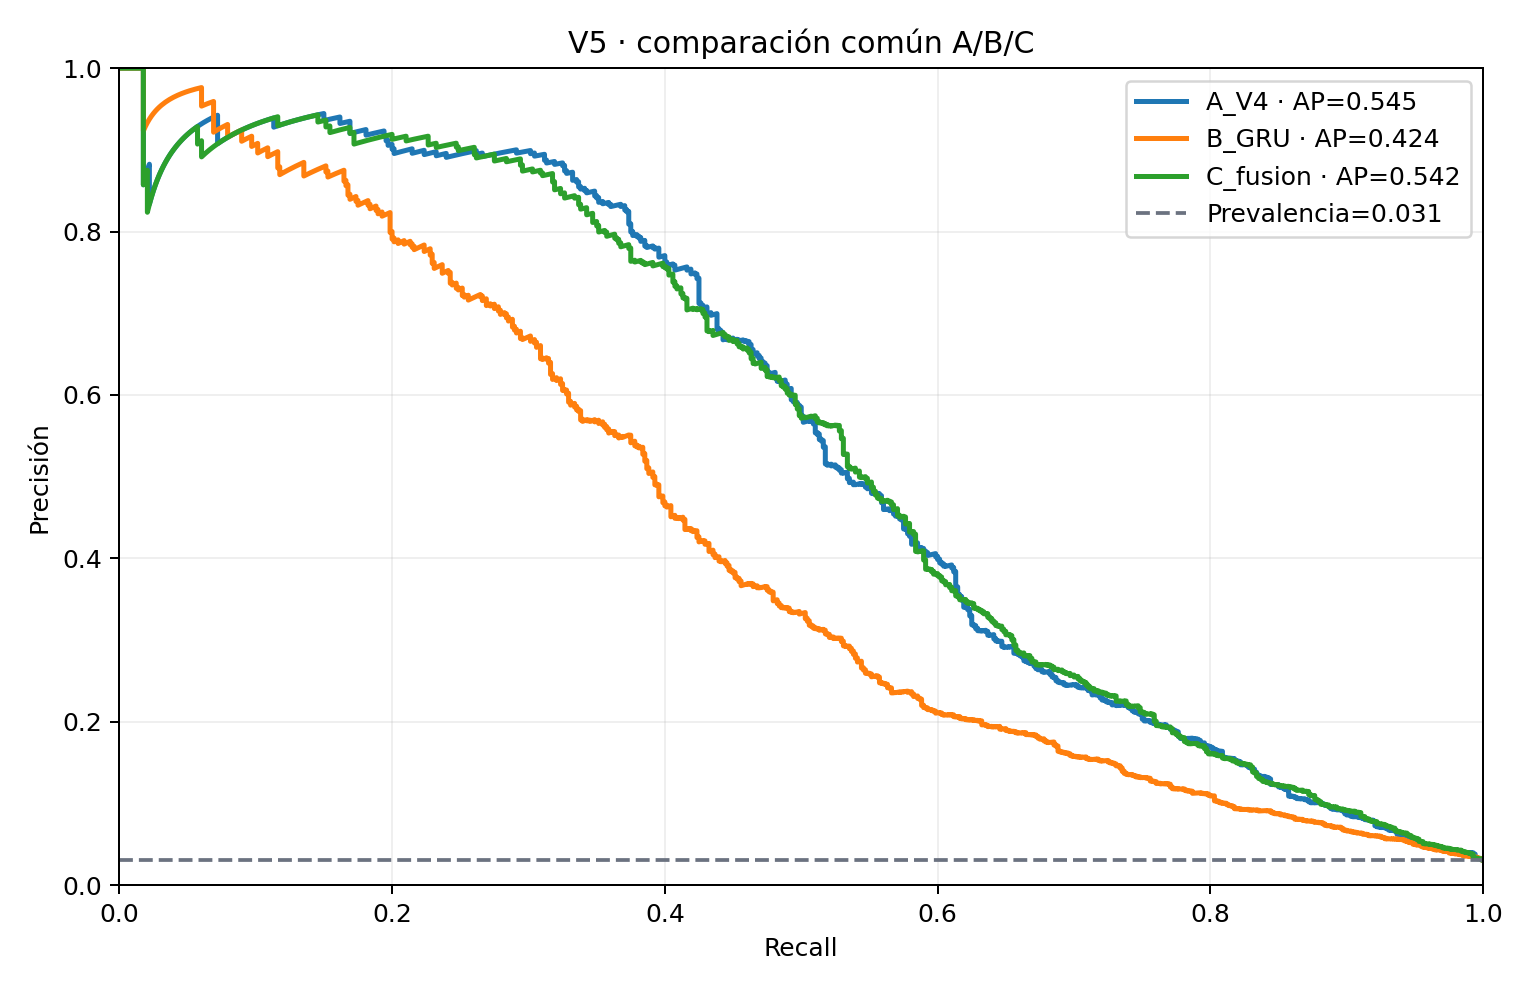

In [8]:
display(Image(filename=str(ROOT/'evidencia/figuras/v5/01_comparacion_abc_validacion.png')))

<div class="section"><h2>6 · Dos intentos de refutar el valor del orden</h2></div>

La permutación conserva los eventos y la transacción objetivo, pero baraja solo los antecedentes. Se repite con cinco semillas. La segunda prueba recorta el historial a 3 y 8 eventos sin reentrenar.

<div class="call warn"><b>Resultado:</b> B original obtiene AP 0.4245 y B permutada 0.4355 ± 0.0021. La diferencia original−permutada es −0.0111. Destruir el orden no perjudica a B; por el contrario, mejora el ranking. No existe evidencia para afirmar que el orden aporte.</div>

In [9]:
pd.DataFrame({
'B original':R['falsificaciones']['original_internal'],
'B permutada':{'auc_pr':R['falsificaciones']['permutation_mean_auc_pr']},
'Historia 3':R['falsificaciones']['historia_3'],
'Historia 8':R['falsificaciones']['historia_8'],
}).T

,auc_pr,roc_auc,precision,recall,f1,tn,fp,fn,tp,cost_q,cost_per_decision_q,alertas_por_100k,threshold
B original,0.424456,0.876738,0.131968,0.748529,0.224377,18118.0,3348.0,171.0,509.0,1320840.0,59.642373,17416.237695,0.033548
B permutada,0.435535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Historia 3,0.425318,0.875684,0.127382,0.747059,0.217652,17986.0,3480.0,172.0,508.0,1348800.0,60.904904,18007.766640,0.033548
Historia 8,0.422504,0.875971,0.130119,0.738235,0.221243,18110.0,3356.0,178.0,502.0,1351680.0,61.034950,17420.753183,0.033548


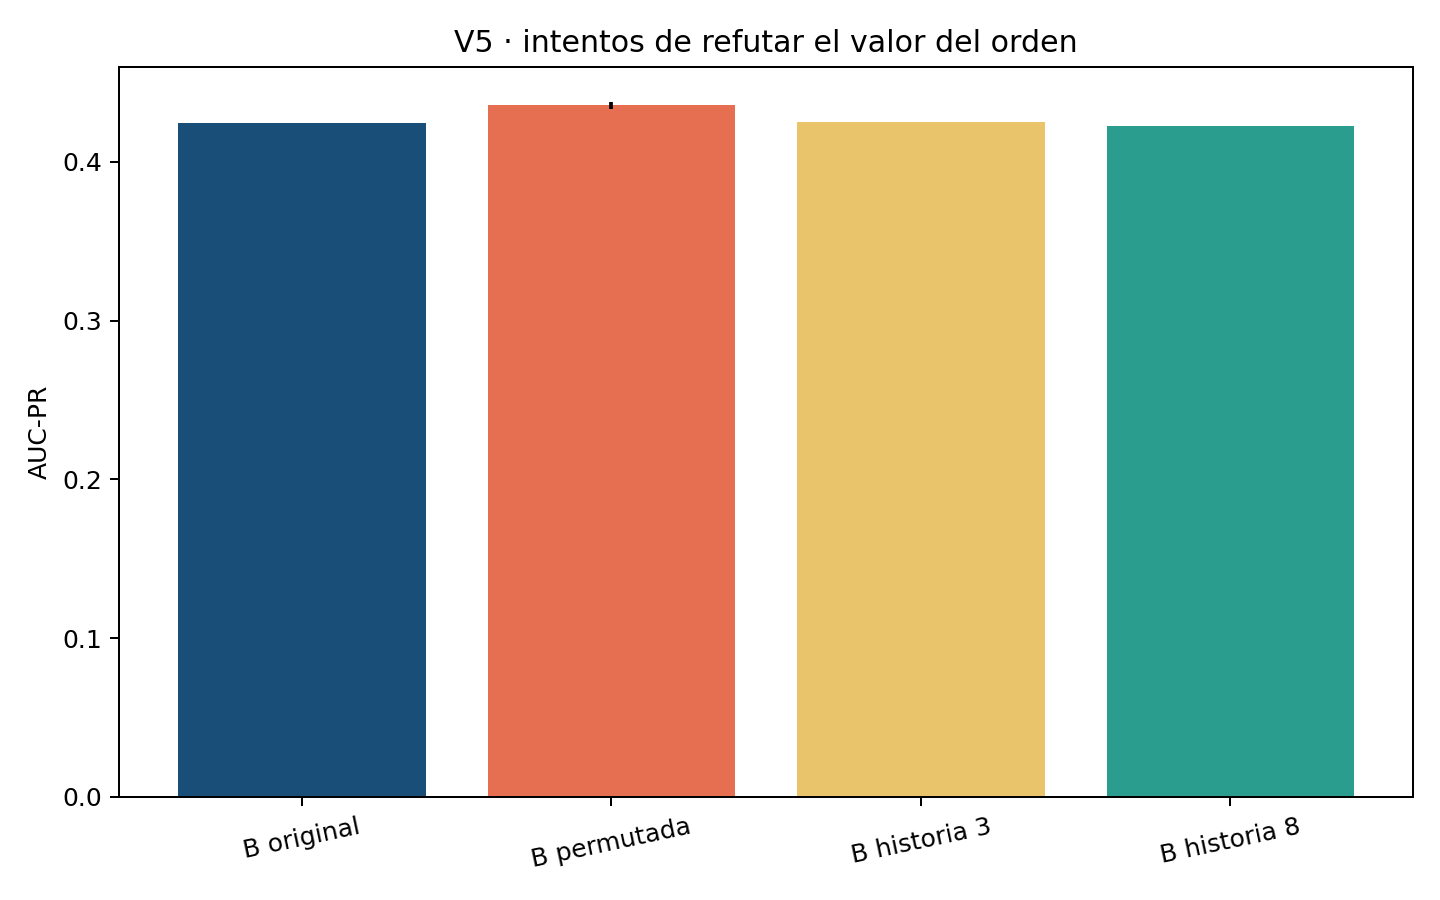

In [10]:
display(Image(filename=str(ROOT/'evidencia/figuras/v5/03_falsificaciones_orden_v5.png')))

<div class="section"><h2>7 · Veredicto de C</h2></div>

C aumenta recall, pero no satisface la regla previa: pierde 0.0020 de AUC-PR y aumenta 0.43 % el costo frente a A en evaluación interna. La apuesta se declara **no útil**, aunque en el benchmark histórico su ranking sea descriptivamente cercano a A. La decisión no se reescribe después de observar ese bloque.

<div class="section"><h2>8 · Umbral y decisión económica</h2></div>

La función de costo suministrada es:

$$C(	au)=Q4{,}200\,FN(	au)+Q180\,FP(	au).$$

El candidato A usa $	au=0.05783$. En el benchmark histórico logra AP 0.5592, precisión 22.15 %, recall 73.27 %, F1 0.3402 y costo Q4,890,000. La proyección mensual es un escenario, no una cifra contable, porque el PDF no fija transacciones por tarjeta.

In [11]:
pd.DataFrame(R['benchmark_historico']).T[['auc_pr','roc_auc','precision','recall','f1','cost_q','alertas_por_100k']]

,auc_pr,roc_auc,precision,recall,f1,cost_q,alertas_por_100k
A_V4,0.559156,0.901268,0.221492,0.732728,0.340160,4890000.0,11513.755772
B_GRU,0.218302,0.865553,0.125534,0.791113,0.216684,5763000.0,21933.597498
C_fusion,0.561675,0.904733,0.160638,0.793707,0.267198,4972680.0,17196.690035


In [12]:
rows=[]
for model,scenarios in R['economia_mensual'].items():
    for tx,values in scenarios.items(): rows.append({'modelo':model,'tx_tarjeta_mes':int(tx),**values})
pd.DataFrame(rows).set_index(['modelo','tx_tarjeta_mes'])

decisiones_mensuales  costo_mensual_q  ahorro_vs_A_q
modelo   tx_tarjeta_mes                                                      
A_V4     5                            7000000     3.864260e+08   0.000000e+00
         12                          16800000     9.274224e+08   0.000000e+00
         20                          28000000     1.545704e+09   0.000000e+00
B_GRU    5                            7000000     4.554137e+08  -6.898771e+07
         12                          16800000     1.092993e+09  -1.655705e+08
         20                          28000000     1.821655e+09  -2.759508e+08
C_fusion 5                            7000000     3.929597e+08  -6.533681e+06
         12                          16800000     9.431032e+08  -1.568083e+07
         20                          28000000     1.571839e+09  -2.613472e+07

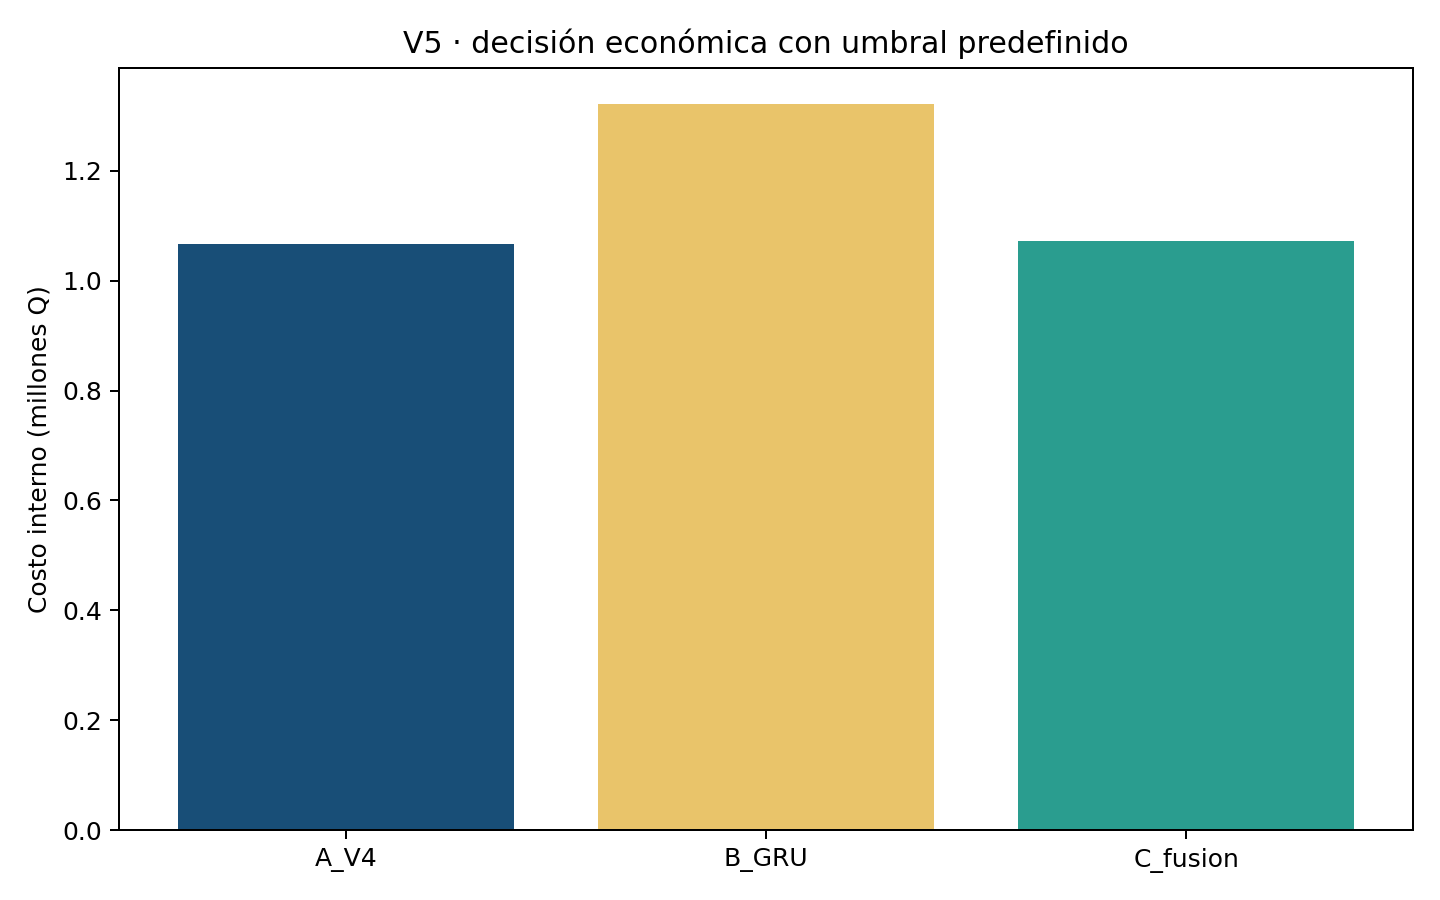

In [13]:
display(Image(filename=str(ROOT/'evidencia/figuras/v5/04_costos_abc_v5.png')))

<div class="section"><h2>9 · Errores, recomendación y límites</h2></div>

Los falsos negativos de alto monto son el error prioritario por su costo. El archivo `falsos_negativos_alto_monto_v5.csv` permite inspeccionarlos sin confundir una predicción con culpabilidad.

Se recomienda **conservar y complementar** el sistema agregado con A para ordenar revisiones humanas, no bloquear automáticamente. La recomendación cambiaría si una identidad bancaria fiable produjera una caída material al permutar, si una cohorte nueva revirtiera el resultado o si la capacidad operativa no absorbiera las alertas.

Limitaciones: identidad proxy, anonimización, benchmark reutilizado, costos académicos, deriva temporal y ausencia de evaluación de privacidad, equidad, latencia, seguridad y apelación.

In [14]:
pd.read_csv(ROOT/'artefactos/v5/metricas_segmentos_v5.csv').sort_values(['dimension','auc_pr'],ascending=[True,False])

,dimension,segmento,n,auc_pr,roc_auc,precision,recall,f1,tn,fp,fn,tp,cost_q,cost_per_decision_q,alertas_por_100k,threshold
2,ProductCD,R,4190,0.806729,0.951295,0.235367,0.891509,0.372414,3364,614,23,189,207120.0,49.431981,19164.677804,0.057829
0,ProductCD,C,9388,0.752721,0.932949,0.366438,0.926772,0.525212,6083,2035,93,1177,756900.0,80.624201,34213.890072,0.057829
3,ProductCD,S,2973,0.647531,0.857714,0.373188,0.715278,0.490476,2656,173,41,103,203340.0,68.395560,9283.551968,0.057829
1,ProductCD,H,2562,0.566140,0.886633,0.196672,0.792683,0.315152,1867,531,34,130,238380.0,93.044496,25800.156128,0.057829
4,ProductCD,W,69468,0.290351,0.844967,0.125786,0.510441,0.201835,63588,4587,633,660,3484260.0,50.156331,7553.117982,0.057829
5,historia,1,2979,0.695544,0.947207,0.172676,0.875000,0.288431,2439,436,13,91,133080.0,44.672709,17690.500168,0.057829
8,historia,9-16,76353,0.566263,0.903728,0.233871,0.735391,0.354882,67077,6555,720,2001,4203900.0,55.058740,11205.846529,0.057829
6,historia,2-3,3520,0.535410,0.888503,0.155319,0.715686,0.255245,3021,397,29,73,193260.0,54.903409,13352.272727,0.057829
7,historia,4-8,5729,0.396810,0.861660,0.145511,0.602564,0.234414,5021,552,62,94,359760.0,62.796300,11275.964392,0.057829
9,monto,"(0.498, 44.0]",22521,0.673637,0.933357,0.311157,0.838469,0.453879,19462,1988,173,898,1084440.0,48.152391,12814.706274,0.057829


<div class="section"><h2>10 · Matriz de evidencias</h2></div>

| Evidencia | Figura o tabla | Conclusión | Limitación |
|---|---|---|---|
| Integridad de datos | Particiones y cobertura | 70/15/15 cronológico; preprocesamiento train-only | Identidad aproximada |
| Comparación A/B | Figura 1 y tabla A/B/C | A supera B en AP, F1 y costo | A posee ingeniería tabular más amplia |
| Valor del orden | Figura 3 | Permutar no reduce AP; no se atribuye valor al orden | Una GRU y una clave proxy |
| Apuesta C | Tabla de hipótesis | No alcanza +0.01 AP ni −5 % costo | Fusión logística específica |
| Decisión económica | Figura 4 | A minimiza costo interno bajo política predefinida | Costos y volumen son escenarios |
| Recomendación y límites | Sección 9 | Complementar con revisión humana | Requiere cohorte nueva y controles productivos |

<div class="section"><h2>11 · Reproducibilidad y declaración de uso de inteligencia artificial</h2></div>

Los pesos, transformaciones, calibradores, umbrales, contrato y puntajes se encuentran en `artefactos/v5/`. El pipeline se ejecuta con `python -u codigo/proyecto1_v5_pipeline.py` y los entregables se reconstruyen con `python codigo/build_v5_deliverables.py`.

Se utilizó asistencia de IA para estructurar código, revisar consistencia, redactar, diseñar HTML/CSS/LaTeX y automatizar auditorías. Los integrantes ejecutaron los experimentos, verificaron alineación temporal, métricas, artefactos y conclusiones; deben poder defender todas las decisiones.

<div class="section"><h2>Referencias APA 7</h2></div>

Cho, K., et al. (2014). Learning phrase representations using RNN encoder–decoder for statistical machine translation. *Proceedings of EMNLP*, 1724–1734. https://doi.org/10.3115/v1/D14-1179

IEEE Computational Intelligence Society. (2019). *IEEE-CIS Fraud Detection* [Data set]. Kaggle. https://www.kaggle.com/competitions/ieee-fraud-detection

Ke, G., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems, 30*.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432